#### In this notebook we use CRU temperature data to explore long term climate trends in East Africa. We focus on Ethiopia Kenya Tanzania and Uganda and match the years to the DHS child survey years.  

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
sns.set_theme(style="whitegrid")
cru_temp_files = {
    "Ethiopia": "Ethiopia_CRU_temp_1901_2024.csv",
    "Kenya": "Kenya_CRU_temp_1901_2024.csv",
    "Tanzania": "Tanzania_CRU_temp_1901_2024.csv",
    "Uganda": "Uganda_CRU_temp_1901_2024.csv",
}
kr_files = [
    "Ethiopia_KR_1992_clean.csv",
    "Ethiopia_KR_1997_clean.csv",
    "Ethiopia_KR_2003_clean.csv",
    "Ethiopia_KR_2008_clean.csv",
    "Ethiopia_KR_2011_clean.csv",
    "Kenya_KR_89_clean.csv",
    "Kenya_KR_93_clean.csv",
    "Kenya_KR_98_clean.csv",
    "Kenya_KR_2003_clean.csv",
    "Kenya_KR_2009_clean.csv",
    "Kenya_KR_2014_clean.csv",
    "Kenya_KR_2022_clean.csv",
    "Tanzania_KR_92_clean.csv",
    "Tanzania_KR_96_clean.csv",
    "Tanzania_KR_99_clean.csv",
    "Tanzania_KR_2004_clean.csv",
    "Tanzania_KR_2010_clean.csv",
    "Tanzania_KR_2015_clean.csv",
    "Tanzania_KR_2022_clean.csv",
    "Uganda_KR_88_clean.csv",
    "Uganda_KR_95_clean.csv",
    "Uganda_KR_2001_clean.csv",
    "Uganda_KR_2006_clean.csv",
    "Uganda_KR_2011_clean.csv",
    "Uganda_KR_2016_clean.csv",
]


#### Here we read each CRU file and keep only year and annual mean temperature. We also make a simple anomaly relative to the period from 1981 to 2010.At the end we have one combined table called climate_all.

In [7]:
# list of KR child files I cleaned already
kr_files = [
    "Ethiopia_KR_1992_clean.csv",
    "Ethiopia_KR_1997_clean.csv",
    "Ethiopia_KR_2003_clean.csv",
    "Ethiopia_KR_2008_clean.csv",
    "Ethiopia_KR_2011_clean.csv",
    "Kenya_KR_89_clean.csv",
    "Kenya_KR_93_clean.csv",
    "Kenya_KR_98_clean.csv",
    "Kenya_KR_2003_clean.csv",
    "Kenya_KR_2009_clean.csv",
    "Kenya_KR_2014_clean.csv",
    "Kenya_KR_2022_clean.csv",
    "Tanzania_KR_92_clean.csv",
    "Tanzania_KR_96_clean.csv",
    "Tanzania_KR_99_clean.csv",
    "Tanzania_KR_2004_clean.csv",
    "Tanzania_KR_2010_clean.csv",
    "Tanzania_KR_2015_clean.csv",
    "Tanzania_KR_2022_clean.csv",
    "Uganda_KR_88_clean.csv",
    "Uganda_KR_95_clean.csv",
    "Uganda_KR_2001_clean.csv",
    "Uganda_KR_2006_clean.csv",
    "Uganda_KR_2011_clean.csv",
    "Uganda_KR_2016_clean.csv",
]



In [8]:
# Ethiopia climate data
ethiopia = pd.read_csv("Ethiopia_CRU_temp_1901_2024.csv")

ethiopia_temp = ethiopia[["YEAR", "ANN"]].copy()
ethiopia_temp = ethiopia_temp.rename(columns={"YEAR": "year", "ANN": "temp_ann"})
ethiopia_temp["country"] = "Ethiopia"

# baseline 1981–2010 for Ethiopia
eth_base = ethiopia_temp[(ethiopia_temp["year"] >= 1981) & (ethiopia_temp["year"] <= 2010)]
eth_base_mean = eth_base["temp_ann"].mean()

ethiopia_temp["temp_anom"] = ethiopia_temp["temp_ann"] - eth_base_mean


In [9]:
# Kenya climate data
kenya = pd.read_csv("Kenya_CRU_temp_1901_2024.csv")

kenya_temp = kenya[["YEAR", "ANN"]].copy()
kenya_temp = kenya_temp.rename(columns={"YEAR": "year", "ANN": "temp_ann"})
kenya_temp["country"] = "Kenya"

# baseline 1981–2010 for Kenya
ken_base = kenya_temp[(kenya_temp["year"] >= 1981) & (kenya_temp["year"] <= 2010)]
ken_base_mean = ken_base["temp_ann"].mean()

kenya_temp["temp_anom"] = kenya_temp["temp_ann"] - ken_base_mean


In [10]:
# Tanzania climate data
tanzania = pd.read_csv("Tanzania_CRU_temp_1901_2024.csv")

tanzania_temp = tanzania[["YEAR", "ANN"]].copy()
tanzania_temp = tanzania_temp.rename(columns={"YEAR": "year", "ANN": "temp_ann"})
tanzania_temp["country"] = "Tanzania"

# baseline 1981–2010 for Tanzania
tan_base = tanzania_temp[(tanzania_temp["year"] >= 1981) & (tanzania_temp["year"] <= 2010)]
tan_base_mean = tan_base["temp_ann"].mean()

tanzania_temp["temp_anom"] = tanzania_temp["temp_ann"] - tan_base_mean


In [11]:
# Uganda climate data
uganda = pd.read_csv("Uganda_CRU_temp_1901_2024.csv")

uganda_temp = uganda[["YEAR", "ANN"]].copy()
uganda_temp = uganda_temp.rename(columns={"YEAR": "year", "ANN": "temp_ann"})
uganda_temp["country"] = "Uganda"

# baseline 1981–2010 for Uganda
uga_base = uganda_temp[(uganda_temp["year"] >= 1981) & (uganda_temp["year"] <= 2010)]
uga_base_mean = uga_base["temp_ann"].mean()

uganda_temp["temp_anom"] = uganda_temp["temp_ann"] - uga_base_mean


In [12]:
# put all four countries into one table
climate_all = pd.concat([
    ethiopia_temp,
    kenya_temp,
    tanzania_temp,
    uganda_temp
])

climate_all.head()


,year,temp_ann,country,temp_anom
0,1901,22.7,Ethiopia,-0.256667
1,1902,22.6,Ethiopia,-0.356667
2,1903,22.7,Ethiopia,-0.256667
3,1904,22.5,Ethiopia,-0.456667
4,1905,22.6,Ethiopia,-0.356667


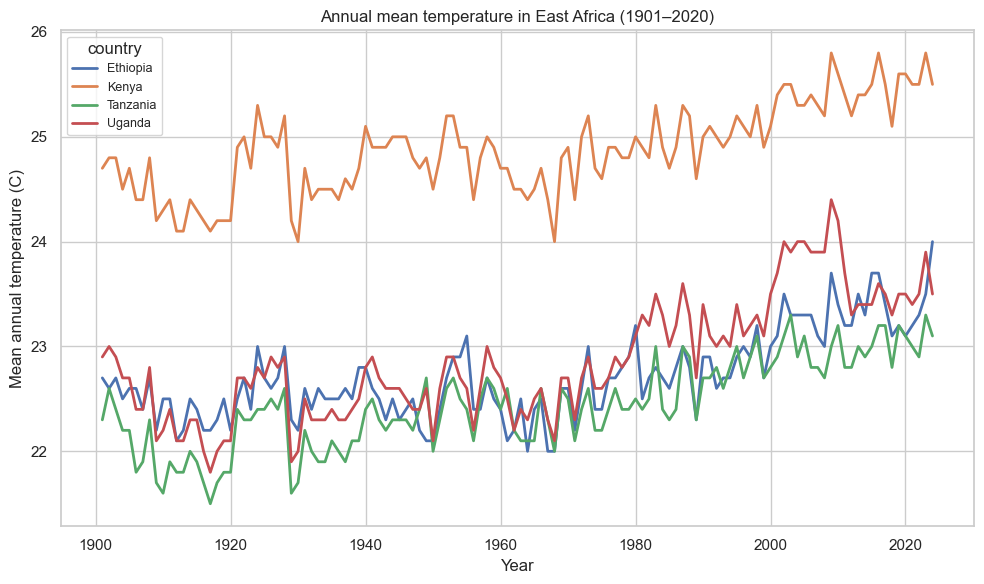

In [13]:
plt.figure(figsize=(10, 6))
for country in ["Ethiopia", "Kenya", "Tanzania", "Uganda"]:
    temp_country = climate_all[climate_all["country"] == country]
    plt.plot(temp_country["year"], temp_country["temp_ann"], label=country, linewidth=2)

plt.xlabel("Year")
plt.ylabel("Mean annual temperature (C)")
plt.title("Annual mean temperature in East Africa (1901–2020)")
plt.legend(title="country", fontsize=9)
plt.tight_layout()
plt.show()


#### The next cells will help show how much has temperature changed by decade? We will  use the climate table to look at long term changes. We then average mean annual temperature by decade for each country (1950s to early 2020s) and plot how it has changed over time.

In [15]:
countries = ["Ethiopia", "Kenya", "Tanzania", "Uganda"]

# from the 1950s and go up to early 2020s
decade_ranges = [
    (1950, 1959, "1950s"),
    (1960, 1969, "1960s"),
    (1970, 1979, "1970s"),
    (1980, 1989, "1980s"),
    (1990, 1999, "1990s"),
    (2000, 2009, "2000s"),
    (2010, 2019, "2010s"),
    (2020, 2024, "early 2020s"),
]

decade_rows = []

for country in countries:
    # keep just this country
    temp_country = climate_all[climate_all["country"] == country]

    for start, end, label in decade_ranges:
        # limit to the decade
        tmp = temp_country[
            (temp_country["year"] >= start) & (temp_country["year"] <= end)
        ]
        avg_temp = tmp["temp_ann"].mean()

        decade_rows.append({
            "country": country,
            "decade_label": label,
            "decade_start": start,
            "decade_end": end,
            "temp_mean": avg_temp,
        })

decade_temp_table = pd.DataFrame(decade_rows)
decade_temp_table.head()


,country,decade_label,decade_start,decade_end,temp_mean
0,Ethiopia,1950s,1950,1959,22.61
1,Ethiopia,1960s,1960,1969,22.27
2,Ethiopia,1970s,1970,1979,22.63
3,Ethiopia,1980s,1980,1989,22.74
4,Ethiopia,1990s,1990,1999,22.85


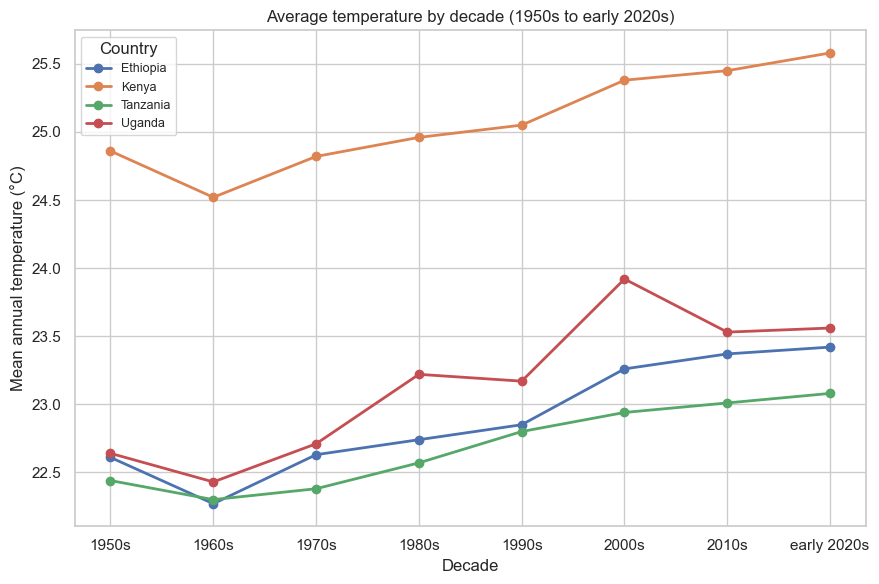

In [16]:
plt.figure(figsize=(9, 6))

for country in countries:
    tmp = decade_temp_table[decade_temp_table["country"] == country]
    tmp = tmp.sort_values("decade_start")

    plt.plot(
        tmp["decade_label"],
        tmp["temp_mean"],
        marker="o",
        linewidth=2,
        label=country,
    )

plt.xlabel("Decade")
plt.ylabel("Mean annual temperature (°C)")
plt.title("Average temperature by decade (1950s to early 2020s)")
plt.legend(title="Country", fontsize=9)
plt.tight_layout()
plt.show()


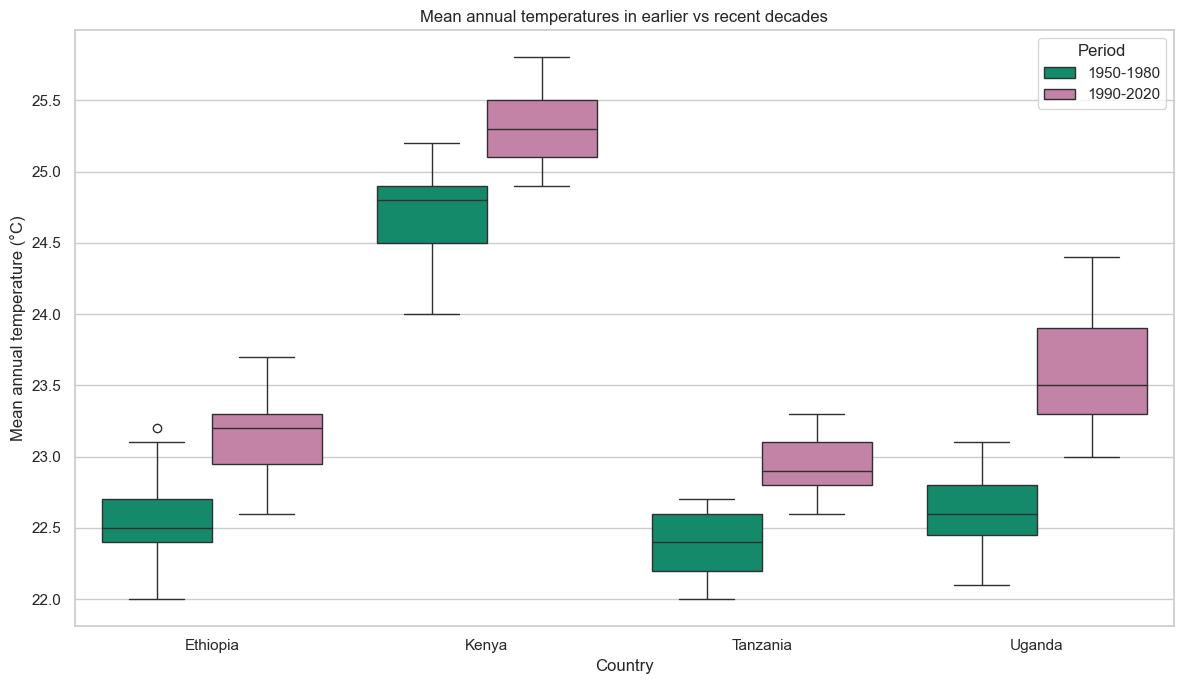

In [34]:
early = climate_all[(climate_all["year"] >= 1950) & (climate_all["year"] <= 1980)].copy()
late = climate_all[(climate_all["year"] >= 1990) & (climate_all["year"] <= 2020)].copy()

early["period"] = "1950-1980"
late["period"] = "1990-2020"

# put the two pieces together
temp_period = pd.concat([early, late], ignore_index=True)

# colorblind friendly palette
period_colors = {
    "1950-1980": "#009E73",   # teal
    "1990-2020": "#CC79A7",   # magenta
}

plt.figure(figsize=(12, 7))
sns.boxplot(
    data=temp_period,
    x="country",
    y="temp_ann",
    hue="period",
    palette=period_colors
)

plt.xlabel("Country")
plt.ylabel("Mean annual temperature (°C)")
plt.title("Mean annual temperatures in earlier vs recent decades")
plt.legend(title="Period")
plt.tight_layout()
plt.show()
